In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import linalg
import matplotlib.colors as colors

In [2]:
# Set font size of plot elements\n",
SMALL_SIZE = 12
MEDIUM_SIZE = 14
BIGGER_SIZE = 18
plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

## Functions

In [3]:
def photons_from_temp(ω_c, temp):
    hbar_ov_k = 7.639e-12
    return (np.exp(hbar_ov_k * ω_c / temp) - 1) ** -1

In [4]:
def temp_from_photons(ω_c, num_photons):
    hbar_ov_k = 7.639e-12 
    return hbar_ov_k * ω_c / np.log(1 / num_photons + 1)

In [5]:
def full_mean_photons_cav(κ, γ, r, g, nT, nc):
    a = (κ + γ)
    b = r * g ** 2 / ((r/2) ** 2 + (r / 2) * ((κ + γ) / 2) + g ** 2)
    num = a * nT + b * nc

    den = a + b

    return num / den

In [6]:
def get_fidelity(num_photons):
    return 1 / (1 + num_photons)

## Preliminary

In the mode cooling paper, it is explained that an external bias magnetic field is used to tune the frequency of the ground state transitions to $2.87\times 2\pi$ GHz, which is the frequency of the cavity mode that is being cooled $\omega_c$.  Changing the strength of the magnetic field should allow us to tune the transition frequency to some other value so that we can cool that mode.  First we want to check how the transition frequencies change if the magnetic field changes.  To verify our calculation here, we'll try to recreate Fig. 1c from Broadway et. al. (2016).

In [7]:
# Define parameters for the ground state Hamiltonian - see Broadway et. al. (2016) for details
D = 2 * np.pi * 2.87e9     # +-1 split from 0 in Hz
γe = -1.76e11          # gyromagnetic ratio for electron in 1 / sT
γn = 1.93e7              # gyromagnetic ratio for nucleus of N 14 in 1 / sT
Q = -5.01e6 * 2 * np.pi    # Quadrupole coupling for N 14 in Hz
Al = -2.14e6 * 2 * np.pi   # Longitudinal hyperfine parameter for N 14 in Hz
At = -2.7e6 * 2 * np.pi    # Tranverse hyperfine parameter for N 14 in Hz

In [8]:
# Define spin operators for electron and nucleus (because they're both spin 1 for N 14 we can use the same operators)
hbar = 1.055e-34         # reduced planck's constant in Js
Sx = 1 / np.sqrt(2) * np.array([[0, 1, 0],
                                   [1, 0, 1],
                                   [0, 1, 0]])
Sy = 1 / np.sqrt(2) * np.array([[0, -1j, 0],
                                   [1j, 0, -1j],
                                   [0, 1j, 0]])
Sz = 1 * np.array([[1, 0, 0],
                      [0, 1, 0],
                      [0, 0, -1]])

In [9]:
# Define the magnetic field values
B = np.linspace(1018, 1028, 1000) / 10000 # units in paper are G, but we want them in T

In [10]:
# Define Hamiltonian
Hs = np.zeros((1000, 9, 9), dtype=complex)
for i in range(B.shape[0]):
    Hs[i] = D * np.kron(Sz @ Sz, np.eye(3)) \
            + γe * B[i] * np.kron(Sz, np.eye(3)) \
            - γn * B[i] * np.kron(np.eye(3), Sz) \
            + Q * np.kron(np.eye(3), Sz @ Sz) \
            + Al * np.kron(Sz, Sz) \
            + At * (np.kron(Sx, Sx) + np.kron(Sy, Sy))

In [11]:
# Calculate the eigenvalues
Es = np.zeros((1000, 9))
for i in range(B.shape[0]):
    Es[i] = np.linalg.eigvalsh(Hs[i])

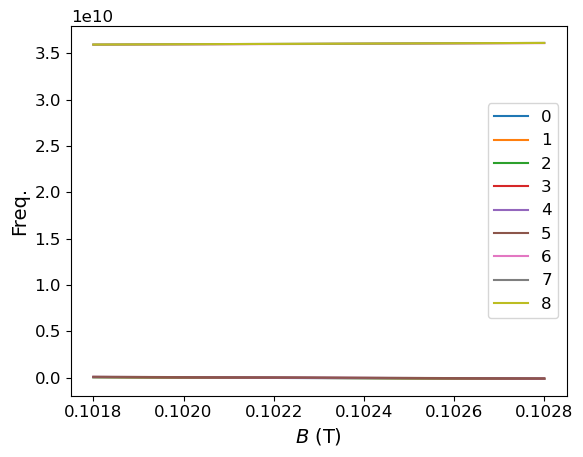

In [12]:
for i in range(9):
    plt.plot(B, Es.T[i], label=str(i))
plt.xlabel("$B$ (T)")
plt.ylabel("Freq.")
plt.legend()

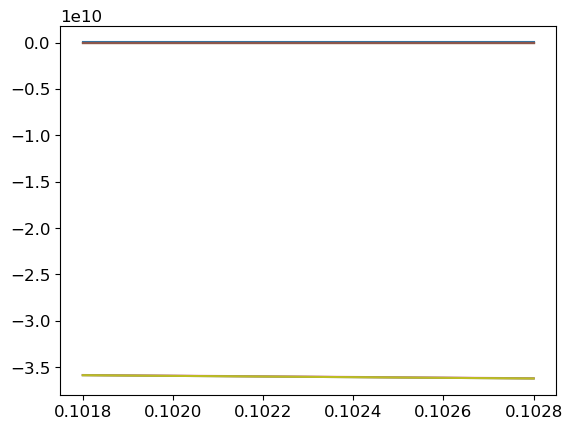

In [13]:
for i in range(9):
    plt.plot(B, Es.T[1] - Es.T[i])

In [14]:
np.linalg.eigh(Hs[0])

EighResult(eigenvalues=array([5.20877163e+07, 6.15371776e+07, 6.90523167e+07, 8.60169170e+07,
       9.98657974e+07, 1.07380943e+08, 3.59065818e+10, 3.59295524e+10,
       3.59295524e+10]), eigenvectors=array([[-0.00000000e+00-0.j,  0.00000000e+00+0.j,  1.00000000e+00+0.j,
         0.00000000e+00+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
         0.00000000e+00+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j],
       [-7.07106781e-01-0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
        -7.07106781e-01+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
         0.00000000e+00+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j],
       [ 0.00000000e+00+0.j,  4.04665658e-01+0.j,  0.00000000e+00+0.j,
         0.00000000e+00+0.j, -1.06376008e-16+0.j,  9.14464709e-01+0.j,
         0.00000000e+00+0.j,  2.23989706e-07+0.j, -5.86165242e-17+0.j],
       [-7.07106781e-01+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
         7.07106781e-01+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
         0.00

In [15]:
D / γe

-0.10245876040684893

In [16]:
H = D * np.kron(Sz @ Sz, np.eye(3)) \
            + γe * 0 * np.kron(Sz, np.eye(3)) \
            - γn * 0 * np.kron(np.eye(3), Sz) \
            + Q * np.kron(np.eye(3), Sz @ Sz) \
            + Al * np.kron(Sz, Sz) \
            + At * (np.kron(Sx, Sx) + np.kron(Sy, Sy))

In [17]:
linalg.eigvalsh(H)

array([1.79708525e+10, 1.79737605e+10, 1.79878171e+10, 1.79878171e+10,
       1.79977445e+10, 1.80047817e+10, 1.80147091e+10, 1.80287656e+10,
       1.80316737e+10])

## Cooling lower frequency

According to the Broadway et. al. (2016) paper, transition frequencies for 14 N can go as low as 100 kHz.  Assuming for now that our analysis of the NV system holds if we couple this transition to a cavity, how close to the ground state is the 100 kHz mode at low temperature and how much does our mode cooling set up improve it?

In [18]:
# First we'll look at the fidelity of this mode to the ground state as the temperature varies
ωc = 2 * np.pi * 100e3   # cavity mode frequency
Ts = np.linspace(.1, 5, 1000)
nTs = photons_from_temp(ωc, Ts)
Fs = get_fidelity(nTs)

Text(0, 0.5, 'Fidelity')

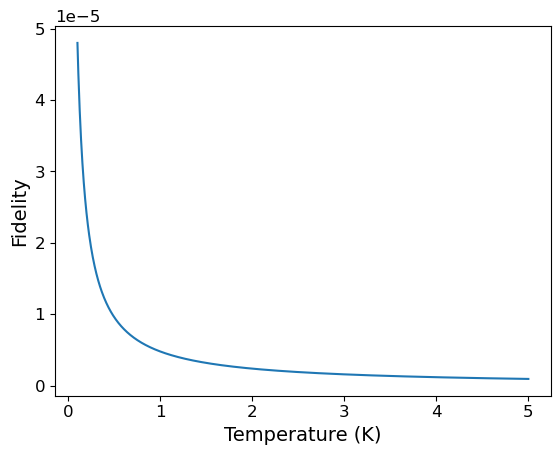

In [19]:
plt.plot(Ts, Fs)
plt.xlabel("Temperature (K)")
plt.ylabel("Fidelity")

In [20]:
# Assume sort of ideal parameters for our mode cooling set up
κ = 0
Q = 1e6
γ = ωc / 1e6
g = 1e6
r = 2 * g
P = 0.8
nc = 0.5 * (1 - P) / P

In [21]:
# Calculate the number of photons in the cavity mode for these temperatures
nbars = full_mean_photons_cav(κ, γ, r, g, nTs, nc)

# Calculate fidelities
mc_Fs = get_fidelity(nbars)

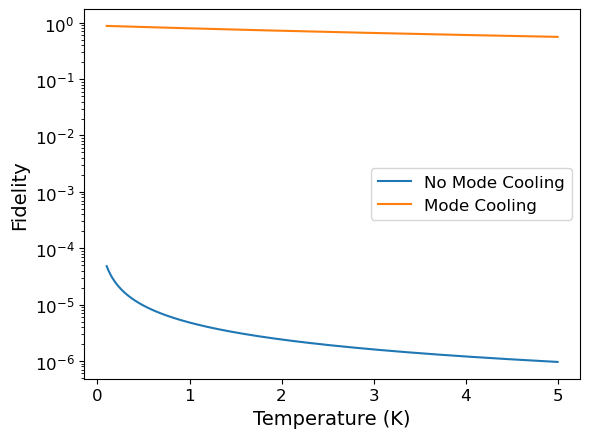

In [22]:
# Plot 
plt.plot(Ts, Fs, label='No Mode Cooling')
plt.plot(Ts, mc_Fs, label='Mode Cooling')
plt.xlabel("Temperature (K)")
plt.ylabel("Fidelity")
plt.yscale('log')
plt.legend()

In [23]:
# Now we should sweep over g and Q at a fixed temperature to see if there are values where this is worse than conventional cooling
g = np.logspace(2, 6, 1000)
Q = np.logspace(2, 6, 1000)

gm, Qm = np.meshgrid(g, Q)

T = 5
nT = photons_from_temp(ωc, T)

In [24]:
nbar_grid = full_mean_photons_cav(κ, ωc / Qm, 2 * gm, gm, nT, nc)
F_grid = get_fidelity(nbar_grid)

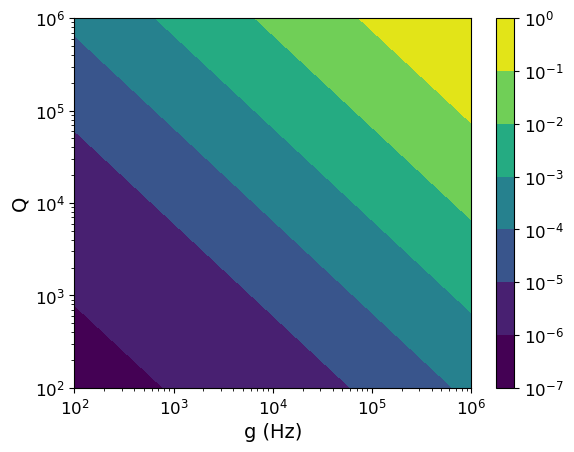

In [25]:
# Plot
plt.contourf(gm, Qm, F_grid, norm=colors.LogNorm(F_grid.min(), F_grid.max()))
plt.xlabel("g (Hz)")
plt.ylabel("Q")
plt.xscale('log')
plt.yscale('log')
plt.colorbar()

So this suggests that you would need $g > 10^4$ and $Q > 10^4$ to beat conventionally cooling the cavity to 1 K.